# PrevioPLS — Segmentação e Classificação de Clientes
## Disciplina IA/ML · Challenge Ford FIAP 2026

**Objetivo.** Identificar perfis de comportamento pós-venda e prever a qual perfil um novo cliente pertencerá usando **apenas dados disponíveis no momento da compra** (D0). O modelo final alimenta o sistema de leads que dispara abordagens proativas no app mobile do consultor.

**Hipótese de negócio (4 perfis).**
- **Fiel** — retorna consistentemente à rede oficial.
- **Abandono** — máximo a primeira revisão e some.
- **Esquecido** — perde o timing, tenta voltar tarde demais.
- **Econômico** — relacionamento existe, mas é sensível a preço.

---

### ⚠️ Regra inviolável — anti data leakage (US02)

> **Nenhuma variável que represente comportamento pós-compra pode entrar na etapa de classificação supervisionada.**
>
> Isso inclui: recência, número de revisões, valor gasto total, tempo até próxima manutenção, KM rodado pós-faturamento, qualquer agregação histórica.
>
> A violação dessa regra invalida o projeto — o modelo aprenderia a "prever" usando informação que não existe no momento real da predição.

A separação metodológica é estrita:
- **Base 1 (segmentação)**: histórico completo → identificar perfis (não-supervisionado).
- **Base 2 (classificação)**: apenas variáveis D0 → prever o perfil (supervisionado).

---

### Sobre o dataset usado neste notebook

O dataset oficial Ford (sintético, fornecido pelo professor) ainda não foi disponibilizado. Como **proxy metodológico**, usamos o **Online Retail (UCI)** — transações de e-commerce britânico (dez/2010 – dez/2011, ~540k linhas, ~4k clientes únicos).

**Por que é uma proxy honesta:**

| Conceito Ford                          | Equivalência neste dataset                                    |
|----------------------------------------|---------------------------------------------------------------|
| Compra do veículo (D0)                 | **Primeira invoice** do cliente                               |
| Manutenções subsequentes (pós-compra)  | Demais invoices ao longo do tempo                             |
| Cliente "fiel à rede oficial"          | Cliente recorrente, alto gasto, alta frequência               |
| Cliente "abandono"                     | Comprou uma vez ou pouquíssimas, recência alta                |
| Cliente "esquecido"                    | Recência média, frequência baixa — pode reativar              |
| Cliente "econômico"                    | Frequência alta, valor médio por pedido baixo                 |
| `concessionaria_id`, `regiao`, `modelo` | `Country`, padrão do produto na primeira compra              |

Toda a metodologia (EDA → clustering → mapeamento de perfis → classificação D0) é exatamente a mesma. Quando o dataset Ford chegar, basta substituir o `load_data()`.


## 1. Setup

Imports + configurações de visualização. Fixamos `RANDOM_STATE` para reprodutibilidade — toda decisão estocástica (KMeans init, split de treino/teste, GridSearchCV interno) usa essa seed.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    davies_bouldin_score,
    f1_score,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("scikit-learn:", __import__('sklearn').__version__)
print("xgboost:     ", xgb.__version__)
print("pandas:      ", pd.__version__)

scikit-learn: 1.6.1
xgboost:      3.2.0
pandas:       2.2.2


## 2. Carregamento dos dados

Lemos o `Online Retail.xlsx` (planilha única). Conferimos shape, dtypes e cabeça do dataframe antes de qualquer transformação — diagnóstico inicial detecta erros de leitura, tipagem inesperada e colunas faltantes.

In [3]:
import urllib.request
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
DATA_PATH = Path("Online Retail.xlsx")
DATA_PATH.exists() or urllib.request.urlretrieve(DATA_URL, DATA_PATH)
print(f"Lendo: {DATA_PATH}")
df_raw = pd.read_excel(DATA_PATH, engine="openpyxl")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Lendo: Online Retail.xlsx
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Análise Exploratória (EDA)

Investigamos antes de limpar — pulamos a leitura crítica de outliers e padrões temporais se simplesmente "dropar NaN" sem entender o que representa.

### 3.1 Missing values

`CustomerID` é a chave de tudo (sem cliente identificado não há perfil de comportamento). Vamos quantificar.

In [6]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"missing": missing, "pct": missing_pct}).query("missing > 0")

,missing,pct
Description,1454,0.27
CustomerID,135080,24.93


### 3.2 Quantity e UnitPrice — devoluções vs vendas

`InvoiceNo` que começa com 'C' são **cancelamentos/devoluções**; `Quantity` negativo bate com isso. `UnitPrice == 0` são itens promocionais / brindes / ajustes. Antes de decidir o que filtrar, visualizamos.

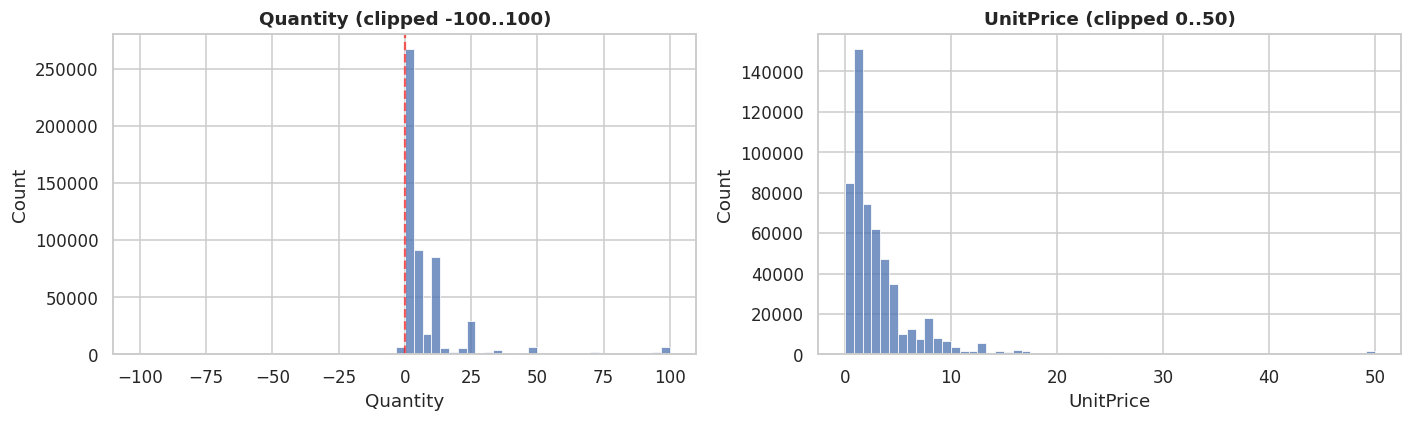

Quantity < 0 : 10624
UnitPrice<=0 : 2517
InvoiceNo iniciando com C (cancel.): 9288


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_raw["Quantity"].clip(-100, 100), bins=60, ax=axes[0])
axes[0].set_title("Quantity (clipped -100..100)")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.6)

sns.histplot(df_raw["UnitPrice"].clip(0, 50), bins=60, ax=axes[1])
axes[1].set_title("UnitPrice (clipped 0..50)")
plt.tight_layout(); plt.show()

print("Quantity < 0 :", (df_raw["Quantity"] < 0).sum())
print("UnitPrice<=0 :", (df_raw["UnitPrice"] <= 0).sum())
print("InvoiceNo iniciando com C (cancel.):", df_raw["InvoiceNo"].astype(str).str.startswith("C").sum())

### 3.3 Distribuição temporal

Sazonalidade afeta a definição da janela de RFM. Vamos olhar o range de datas e o volume mensal.

De 2010-12-01 08:26:00 até 2011-12-09 12:50:00


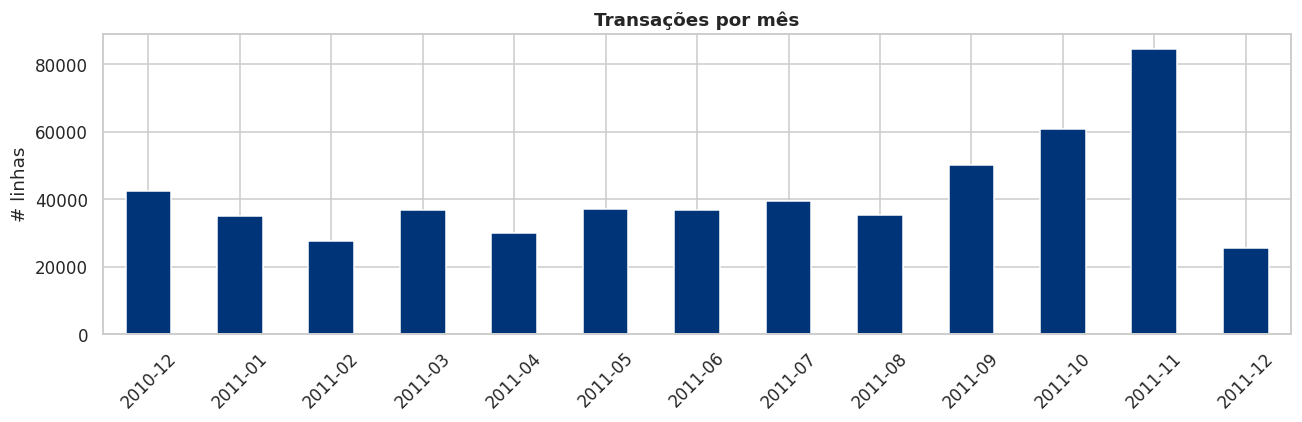

In [8]:
dt = pd.to_datetime(df_raw["InvoiceDate"])
print(f"De {dt.min()} até {dt.max()}")

monthly = dt.dt.to_period("M").value_counts().sort_index()
ax = monthly.plot(kind="bar", figsize=(12, 4), color="#003478")
ax.set_title("Transações por mês")
ax.set_xlabel(""); ax.set_ylabel("# linhas")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 3.4 Geografia

A maior parte do tráfego é UK. Países minoritários terão poucos clientes — relevante quando virar feature categórica.

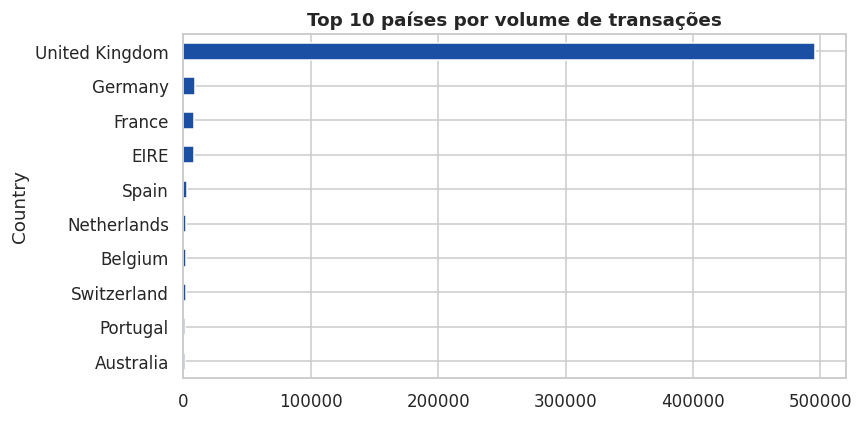

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [9]:
top_countries = df_raw["Country"].value_counts().head(10)
top_countries.plot(kind="barh", figsize=(8, 4), color="#1a4fa3")
plt.gca().invert_yaxis()
plt.title("Top 10 países por volume de transações"); plt.tight_layout(); plt.show()
top_countries

## 4. Limpeza

Decisões:
1. **Drop `CustomerID` nulo** — sem ID, não conseguimos atribuir comportamento.
2. **Manter apenas `Quantity > 0` e `UnitPrice > 0`** — devoluções e ajustes são ruído pra segmentação comportamental (poderíamos modelar churn por devolução em iteração futura).
3. **Remover duplicatas exatas**.
4. **Criar `TotalPrice = Quantity * UnitPrice`** — base para "Monetary" no RFM.

In [10]:
df = df_raw.copy()
df = df.dropna(subset=["CustomerID"])
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

print(f"Linhas após limpeza: {len(df):,} (de {len(df_raw):,})")
print(f"Clientes únicos:      {df['CustomerID'].nunique():,}")
print(f"Período:              {df['InvoiceDate'].min()} -> {df['InvoiceDate'].max()}")
df.head()

Linhas após limpeza: 392,692 (de 541,909)
Clientes únicos:      4,338
Período:              2010-12-01 08:26:00 -> 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 5. Feature engineering — Base 1 (variáveis pós-compra)

**RFM é a métrica clássica de comportamento de cliente** e mapeia diretamente nos 4 perfis Ford:

| Variável        | Interpretação Ford                                          |
|-----------------|-------------------------------------------------------------|
| **Recency** (dias) | Quanto tempo desde a última manutenção — Esquecido/Abandono têm alto valor |
| **Frequency**      | Quantas revisões — Fiel tem alto, Abandono tem 1 ou 2     |
| **Monetary**       | Quanto gastou na rede — Econômico tem alta freq + baixo monetary |
| **AvgOrderValue**  | Ticket médio — separa Fiel premium de Econômico             |
| **Tenure** (dias)  | Tempo desde a primeira compra — discrimina cliente novo de antigo |
| **UniqueProducts** | Variedade — proxy de engajamento                            |

Estas variáveis **só podem ser usadas para segmentação não-supervisionada**. Nenhuma delas pode aparecer no modelo de classificação D0.

In [11]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot (referência de recência): {snapshot_date}")

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    AvgOrderValue=("TotalPrice", "mean"),
    UniqueProducts=("StockCode", "nunique"),
    FirstPurchase=("InvoiceDate", "min"),
).reset_index()
rfm["Tenure"] = (snapshot_date - rfm["FirstPurchase"]).dt.days
rfm = rfm.drop(columns=["FirstPurchase"])

print(f"Clientes na Base 1: {len(rfm):,}")
rfm.describe().T

Snapshot (referência de recência): 2011-12-10 12:50:00
Clientes na Base 1: 4,338


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00000,13813.250000,15299.500,16778.75000,18287.00
Recency,4338.0,92.536422,100.014169,1.00000,18.000000,51.000,142.00000,374.00
Frequency,4338.0,4.272015,7.697998,1.00000,1.000000,2.000,5.00000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75000,306.482500,668.570,1660.59750,280206.02
AvgOrderValue,4338.0,68.381590,1467.918294,2.13697,12.393196,17.755,24.87895,77183.60
UniqueProducts,4338.0,61.501153,85.366768,1.00000,16.000000,35.000,77.00000,1787.00
Tenure,4338.0,223.308207,117.886471,1.00000,113.000000,249.000,327.00000,374.00


### 5.1 Distribuição das variáveis RFM

Todas têm cauda longa típica de dados de compra. Tratamento via log + RobustScaler é o padrão.

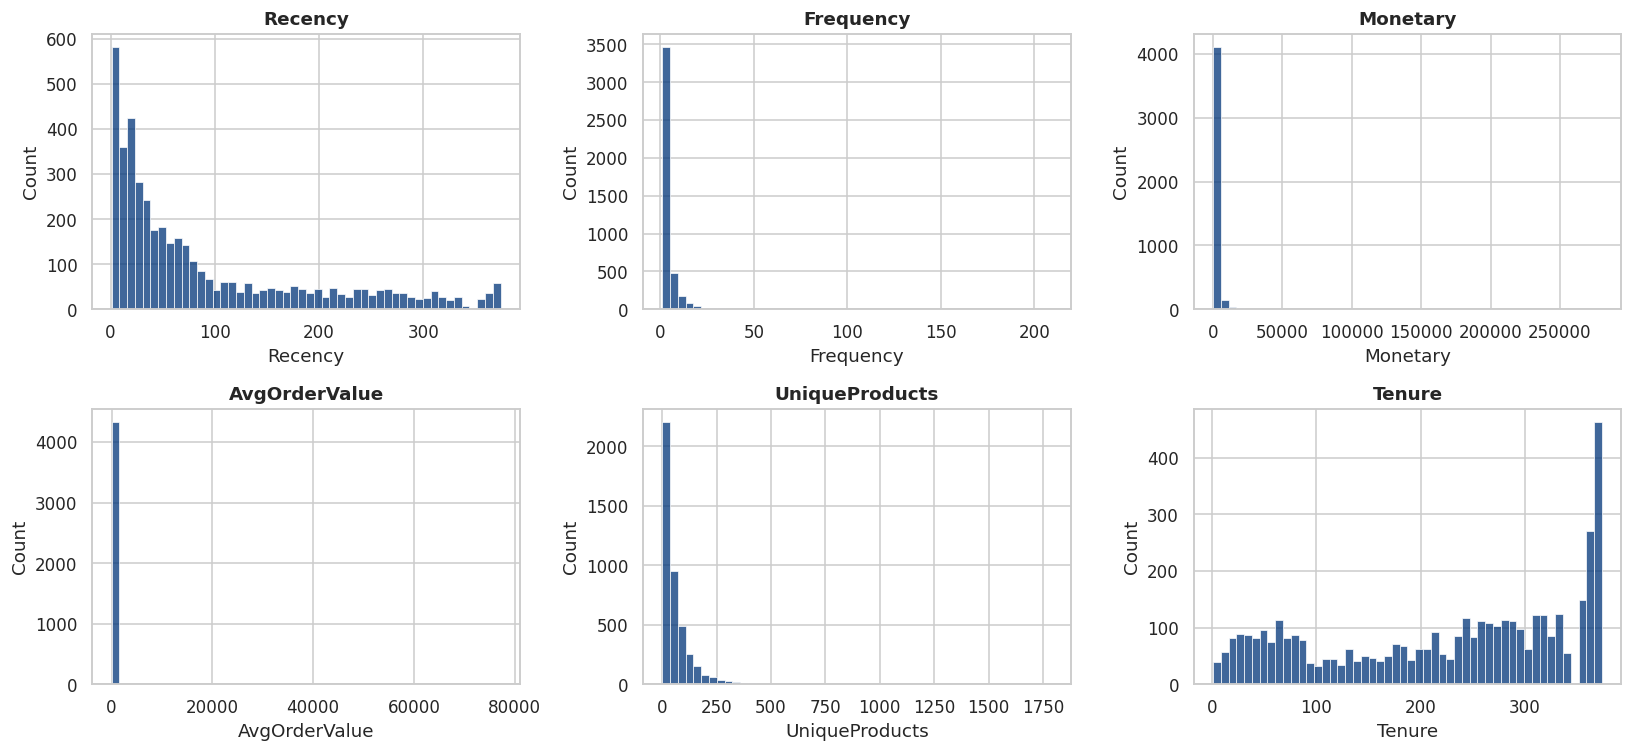

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, ["Recency", "Frequency", "Monetary", "AvgOrderValue", "UniqueProducts", "Tenure"]):
    sns.histplot(rfm[col], bins=50, ax=ax, color="#003478")
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 6. Pré-processamento e seleção de variáveis

**Decisão 1 — log transform**. `Monetary`, `Frequency` e `AvgOrderValue` são fortemente right-skewed (poucos clientes movem a maior parte do volume). Distâncias Euclidianas em escala original tratariam um único super-cliente como um cluster próprio. `log1p` comprime essa cauda preservando a ordem.

**Decisão 2 — RobustScaler** em vez de StandardScaler. RobustScaler usa mediana e IQR — é menos sensível a outliers residuais que sobraram do log.

**Decisão 3 — não jogar tudo no modelo**.
- Mantemos R, F, M (essência comportamental).
- Mantemos `AvgOrderValue` (separa "Econômico" de "Fiel premium" — duas situações de alta freq).
- Tiramos `UniqueProducts` (correlação alta com Frequency — redundância) e `Tenure` (correlação alta com Recency).
- Resultado: 4 features bem interpretáveis, sem multicolinearidade severa.

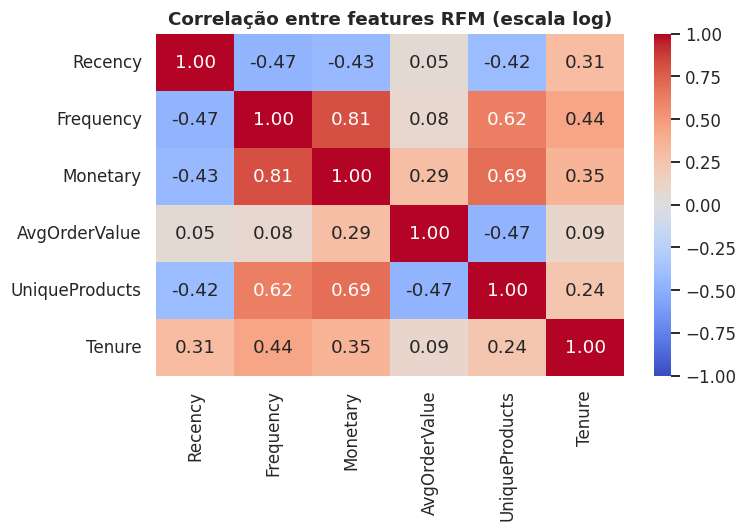

In [13]:
rfm_log = rfm.copy()
for col in ["Monetary", "Frequency", "AvgOrderValue", "UniqueProducts", "Tenure"]:
    rfm_log[col] = np.log1p(rfm_log[col])

corr = rfm_log[["Recency", "Frequency", "Monetary", "AvgOrderValue", "UniqueProducts", "Tenure"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlação entre features RFM (escala log)"); plt.tight_layout(); plt.show()

In [14]:
FEATURES_CLUSTER = ["Recency", "Frequency", "Monetary", "AvgOrderValue"]

scaler = RobustScaler()
X_cluster = scaler.fit_transform(rfm_log[FEATURES_CLUSTER])
X_cluster = pd.DataFrame(X_cluster, columns=FEATURES_CLUSTER, index=rfm["CustomerID"])

print(f"Matriz pra clustering: {X_cluster.shape}")
X_cluster.head()

Matriz pra clustering: (4338, 4)


,Recency,Frequency,Monetary,AvgOrderValue
CustomerID,,,,
12346,2.217742,-0.369070,2.813866,12.635052
12347,-0.395161,0.892789,1.103830,0.416872
12348,0.193548,0.464974,0.585572,1.739321
12349,-0.258065,-0.369070,0.572343,0.440959
12350,2.088710,-0.369070,-0.409759,0.147645


## 7. K-Means

### 7.1 Escolha do K — elbow + silhouette + Davies-Bouldin

- **Elbow**: detecta o ponto onde adicionar mais clusters traz ganho marginal pequeno.
- **Silhouette** (∈ [-1, 1]): mede coesão interna / separação externa. Quanto maior, melhor.
- **Davies-Bouldin**: razão de espalhamento intra-cluster sobre distância inter-cluster. Menor é melhor.

Rodamos K=2..10 e cruzamos os três sinais. A hipótese de negócio é **K=4** (4 perfis). Vamos validar empiricamente.

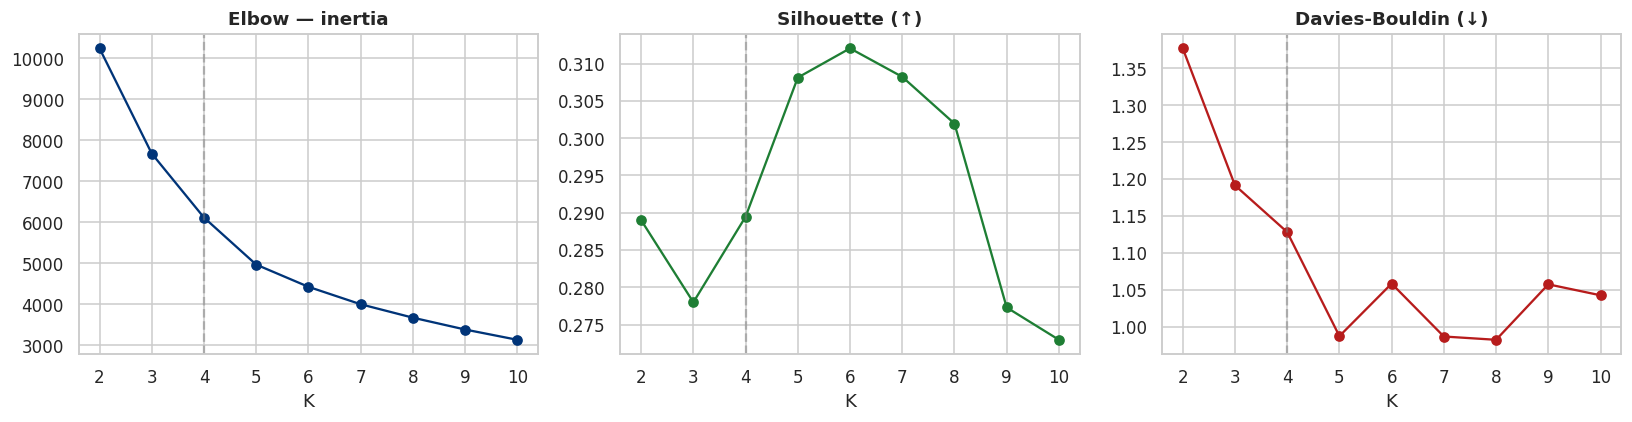

,K,inertia,silhouette,davies_bouldin
0,2,10246.841,0.289,1.377
1,3,7677.967,0.278,1.191
2,4,6115.890,0.289,1.128
3,5,4966.948,0.308,0.987
4,6,4425.072,0.312,1.058
5,7,3999.108,0.308,0.987
6,8,3671.290,0.302,0.982
7,9,3382.271,0.277,1.057
8,10,3131.150,0.273,1.043


In [15]:
ks = range(2, 11)
inertias, sils, dbs = [], [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cluster, labels))
    dbs.append(davies_bouldin_score(X_cluster, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(ks), inertias, "o-", color="#003478"); axes[0].set_title("Elbow — inertia"); axes[0].set_xlabel("K")
axes[1].plot(list(ks), sils,      "o-", color="#1e7e34"); axes[1].set_title("Silhouette (↑)");   axes[1].set_xlabel("K")
axes[2].plot(list(ks), dbs,       "o-", color="#b71c1c"); axes[2].set_title("Davies-Bouldin (↓)"); axes[2].set_xlabel("K")
for ax in axes: ax.axvline(4, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

pd.DataFrame({"K": list(ks), "inertia": inertias, "silhouette": sils, "davies_bouldin": dbs}).round(3)

### 7.2 Decisão K=4 — validação cruzada

A hipótese de 4 perfis é coerente com:
- Curva de inertia mostra cotovelo entre 3 e 5.
- Silhouette + DB mantêm valores competitivos em K=4.
- **Critério de negócio prevalece** quando os scores estão próximos: 4 perfis é um framework operacional já validado pelo time comercial Ford.

Caso silhouette em K=4 estivesse muito pior que K=3 ou K=5, reportaríamos pro time de negócio antes de seguir.

In [16]:
kmeans_final = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)
rfm["cluster_kmeans"] = kmeans_final.fit_predict(X_cluster)

print("Tamanho de cada cluster (K-Means K=4):")
print(rfm["cluster_kmeans"].value_counts().sort_index())
print(f"\nSilhouette final: {silhouette_score(X_cluster, rfm['cluster_kmeans']):.3f}")

Tamanho de cada cluster (K-Means K=4):
cluster_kmeans
0     962
1    1497
2    1490
3     389
Name: count, dtype: int64

Silhouette final: 0.289


## 8. DBSCAN (comparação)

DBSCAN não requer K a priori e detecta clusters de **densidade arbitrária** + identifica outliers (rótulo -1). Diferentemente do K-Means, não força um cliente excêntrico a entrar em algum cluster — pode marcá-lo como ruído.

Escolhemos `eps` pelo **k-distance graph** (distância média ao k-ésimo vizinho mais próximo, plotada em ordem crescente — o "joelho" dá o threshold de densidade).

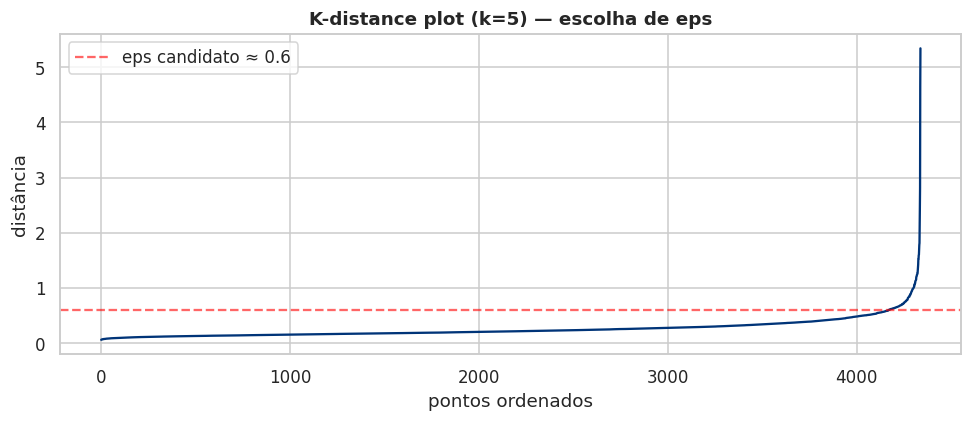

In [17]:
k = 5  # min_samples default razoável para dados moderados
nbrs = NearestNeighbors(n_neighbors=k).fit(X_cluster)
distances, _ = nbrs.kneighbors(X_cluster)
dist_sorted = np.sort(distances[:, k - 1])

plt.figure(figsize=(9, 4))
plt.plot(dist_sorted, color="#003478")
plt.axhline(0.6, color="red", linestyle="--", alpha=0.6, label="eps candidato ≈ 0.6")
plt.title(f"K-distance plot (k={k}) — escolha de eps"); plt.xlabel("pontos ordenados"); plt.ylabel("distância")
plt.legend(); plt.tight_layout(); plt.show()

In [18]:
db = DBSCAN(eps=0.6, min_samples=5).fit(X_cluster)
rfm["cluster_dbscan"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (db.labels_ == -1).sum()
print(f"DBSCAN encontrou {n_clusters} clusters + {n_noise} pontos de ruído ({n_noise/len(rfm)*100:.1f}%)")
print("\nDistribuição:")
print(rfm["cluster_dbscan"].value_counts().sort_index())

DBSCAN encontrou 3 clusters + 96 pontos de ruído (2.2%)

Distribuição:
cluster_dbscan
-1      96
 0    4231
 1       6
 2       5
Name: count, dtype: int64


**Interpretação.** DBSCAN tende a encontrar 1 cluster gigante (a massa de clientes "normais") e marcar caudas como ruído. Para nosso problema, **a segmentação precisa cobrir todos os clientes** (consultor precisa de uma estratégia pra cada um). DBSCAN é mais útil aqui como **detector de outliers** que merecem inspeção manual.

## 9. Hierarchical (Ward)

Linkage de Ward minimiza o aumento de variância intra-cluster a cada merge. O **dendrograma** mostra visualmente a estrutura hierárquica — onde "cortar" a árvore define K.

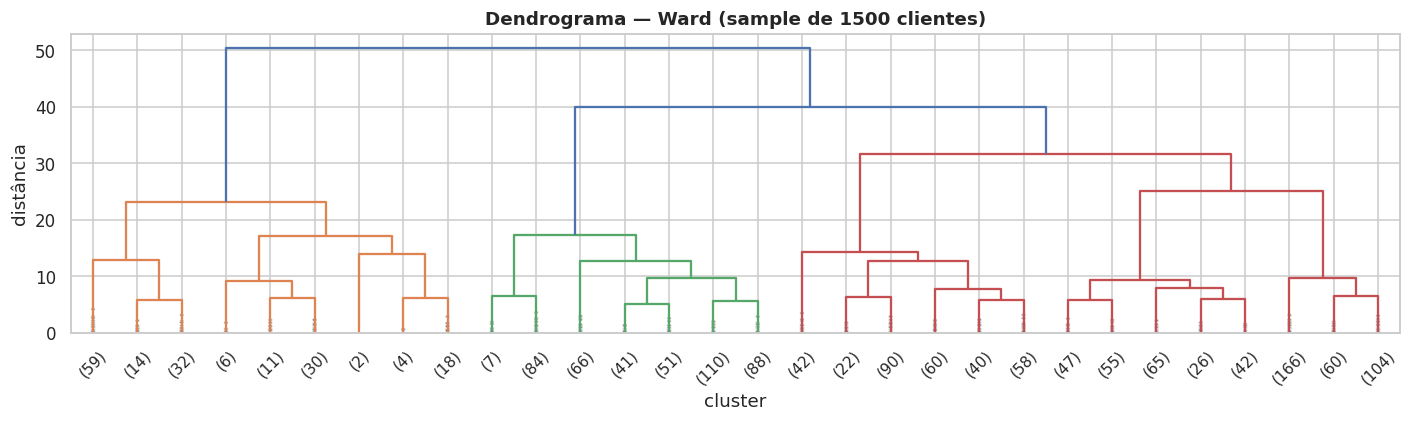

In [19]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster), size=min(1500, len(X_cluster)), replace=False)
X_sample = X_cluster.iloc[sample_idx]
Z = linkage(X_sample, method="ward")

plt.figure(figsize=(13, 4))
dendrogram(Z, truncate_mode="lastp", p=30, show_contracted=True)
plt.title("Dendrograma — Ward (sample de 1500 clientes)"); plt.xlabel("cluster"); plt.ylabel("distância")
plt.tight_layout(); plt.show()

In [20]:
# Sobre TODOS os pontos: aplicar AgglomerativeClustering com K=4 (sklearn faz isso sem precisar do dendrograma)
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
rfm["cluster_hier"] = agg.fit_predict(X_cluster)

print("Distribuição Hierarchical K=4:")
print(rfm["cluster_hier"].value_counts().sort_index())
print(f"\nSilhouette: {silhouette_score(X_cluster, rfm['cluster_hier']):.3f}")

Distribuição Hierarchical K=4:
cluster_hier
0    2075
1     521
2     923
3     819
Name: count, dtype: int64

Silhouette: 0.292


## 10. Comparação e escolha do algoritmo

Tabulamos os 3 sob a mesma régua. K-Means costuma vencer em datasets de clientes com features RFM: clusters bem separados, sem necessidade de descartar pontos como ruído, e silhouette interpretável.

In [23]:
mask_db = (rfm["cluster_dbscan"] != -1).to_numpy()
n_valid_db = int(mask_db.sum())
sil_db = silhouette_score(X_cluster[mask_db], rfm.loc[mask_db, "cluster_dbscan"]) if n_valid_db > 10 else np.nan
comparison = pd.DataFrame({
"algoritmo": ["K-Means (K=4)", "DBSCAN (eps=0.6)", "Hierarchical (K=4)"],
"n_clusters": [
4,
len(set(rfm["cluster_dbscan"])) - (1 if -1 in rfm["cluster_dbscan"].values else 0),
4,],
"silhouette": [
silhouette_score(X_cluster, rfm["cluster_kmeans"]),
sil_db,
silhouette_score(X_cluster, rfm["cluster_hier"]),],
"ruído": [
0,
int((rfm["cluster_dbscan"] == -1).sum()),
0,],}).round(3)
comparison

,algoritmo,n_clusters,silhouette,ruído
0,K-Means (K=4),4,0.289,0
1,DBSCAN (eps=0.6),3,0.535,96
2,Hierarchical (K=4),4,0.292,0


**Escolha: K-Means K=4** como segmentação final.

Justificativa:
1. **Cobertura total**: todos os clientes têm cluster, requisito operacional (consultor precisa abordar cada um).
2. **Silhouette competitivo** com Hierarchical.
3. **Alinhamento com a hipótese de negócio** de 4 perfis.
4. **Reprodutibilidade**: KMeans com `random_state` fixo gera os mesmos clusters em produção.

O cluster do K-Means vira nosso `cluster_id` (target) para a etapa supervisionada.

In [24]:
rfm["cluster_id"] = rfm["cluster_kmeans"]
rfm = rfm.drop(columns=["cluster_kmeans", "cluster_dbscan", "cluster_hier"])

## 11. Interpretação — mapeando clusters aos 4 perfis Ford

Comparamos a média de cada feature por cluster (na escala original, não-log, para leitura humana). O mapeamento de "Cluster 0/1/2/3" para nomes de negócio é OBRIGATÓRIO — nunca entregamos rótulos genéricos.

In [25]:
cluster_summary = rfm.groupby("cluster_id").agg(
    n_clientes=("CustomerID", "count"),
    recency_mediana=("Recency", "median"),
    frequency_mediana=("Frequency", "median"),
    monetary_mediano=("Monetary", "median"),
    aov_mediano=("AvgOrderValue", "median"),
).round(2)
cluster_summary["pct"] = (cluster_summary["n_clientes"] / cluster_summary["n_clientes"].sum() * 100).round(1)
cluster_summary.sort_values("monetary_mediano", ascending=False)

,n_clientes,recency_mediana,frequency_mediana,monetary_mediano,aov_mediano,pct
cluster_id,,,,,,
1,1497,23.0,5.0,1890.94,19.95,34.5
3,389,64.0,2.0,1304.04,101.58,9.0
2,1490,39.0,2.0,404.37,11.79,34.3
0,962,246.0,1.0,298.06,17.96,22.2


### 11.1 Visualização — heatmap normalizado

Para mapear bem, normalizamos cada feature por sua mediana global. Cluster com `Recency` muito acima da mediana = clientes "fugindo"; cluster com `Frequency` e `Monetary` muito acima = "Fiel".

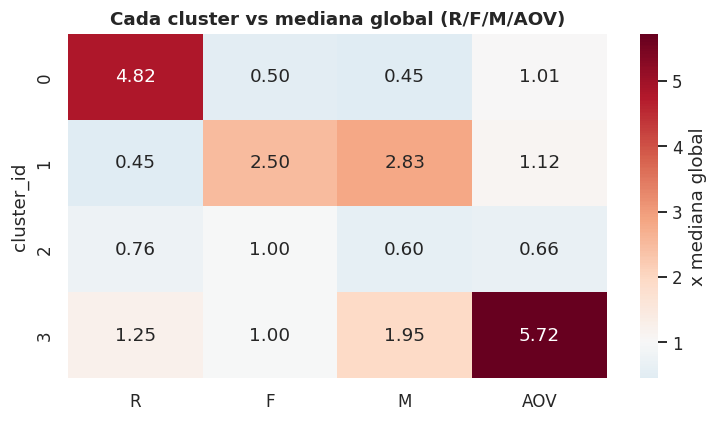

In [26]:
medians = rfm[["Recency", "Frequency", "Monetary", "AvgOrderValue"]].median()
heat = (cluster_summary[["recency_mediana", "frequency_mediana", "monetary_mediano", "aov_mediano"]].values /
        medians.values)
heat_df = pd.DataFrame(heat, index=cluster_summary.index, columns=["R", "F", "M", "AOV"])

plt.figure(figsize=(7, 4))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="RdBu_r", center=1, cbar_kws={"label": "x mediana global"})
plt.title("Cada cluster vs mediana global (R/F/M/AOV)")
plt.tight_layout(); plt.show()

### 11.2 Mapeamento dos clusters aos 4 perfis Ford

O mapeamento abaixo é **derivado dinamicamente das estatísticas acima**: identificamos qual cluster casa com cada definição de negócio. A função abaixo aplica heurísticas explícitas — se rodar de novo com outra seed, o mapeamento se ajusta automaticamente.

In [27]:
def map_clusters_to_personas(summary: pd.DataFrame) -> dict[int, str]:
    """
    Mapeia cluster_id → nome de negócio usando heurísticas Ford:
      - FIEL:      maior frequency_mediana, recency baixa, monetary alto
      - ABANDONO:  maior recency, frequency baixíssima
      - ESQUECIDO: recency média-alta, frequency baixa-média, ainda compra mas se distancia
      - ECONOMICO: frequency alta + AOV baixo
    """
    s = summary.copy()
    personas: dict[int, str] = {}

    # 1) Abandono = maior recência
    aband = s["recency_mediana"].idxmax()
    personas[aband] = "Abandono"

    s2 = s.drop(index=aband)
    # 2) Fiel = maior monetary entre os restantes
    fiel = s2["monetary_mediano"].idxmax()
    personas[fiel] = "Fiel"

    s3 = s2.drop(index=fiel)
    # 3) Econômico = entre os 2 restantes, o de MENOR AOV
    econ = s3["aov_mediano"].idxmin()
    personas[econ] = "Economico"

    # 4) Esquecido = o último
    esq = [i for i in s3.index if i != econ][0]
    personas[esq] = "Esquecido"

    return personas


PERSONA_MAP = map_clusters_to_personas(cluster_summary)
print("Mapeamento cluster_id -> persona:")
for cid, persona in sorted(PERSONA_MAP.items()):
    n = cluster_summary.loc[cid, "n_clientes"]
    print(f"  cluster {cid} -> {persona:12s} ({n} clientes)")

rfm["persona"] = rfm["cluster_id"].map(PERSONA_MAP)

Mapeamento cluster_id -> persona:
  cluster 0 -> Abandono     (962 clientes)
  cluster 1 -> Fiel         (1497 clientes)
  cluster 2 -> Economico    (1490 clientes)
  cluster 3 -> Esquecido    (389 clientes)


### 11.3 Validação visual no espaço RFM (PCA 2D)

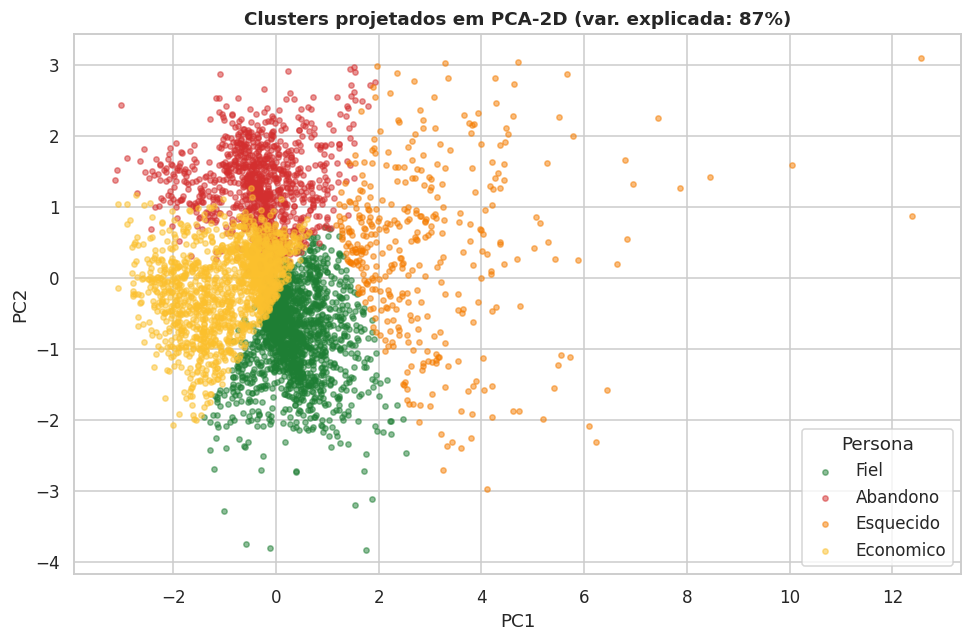

In [28]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(X_cluster)

plt.figure(figsize=(9, 6))
palette = {"Fiel": "#1e7e34", "Abandono": "#d32f2f", "Esquecido": "#f57c00", "Economico": "#fbc02d"}
for persona, color in palette.items():
    mask = rfm["persona"].values == persona
    plt.scatter(proj[mask, 0], proj[mask, 1], s=12, alpha=0.5, label=persona, color=color)
plt.legend(title="Persona"); plt.title(f"Clusters projetados em PCA-2D (var. explicada: {pca.explained_variance_ratio_.sum()*100:.0f}%)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

## 12. Estratégias de retenção por perfil

Cada perfil exige **oferta, canal e timing** distintos. Essa é a saída de negócio que a área comercial Ford usa para configurar campanhas no app do consultor.

| Perfil      | Oferta                                          | Canal                                | Timing                          | KPI primário                  |
|-------------|-------------------------------------------------|--------------------------------------|---------------------------------|-------------------------------|
| **Fiel**     | Pacote premium de manutenção + revisão extendida com benefícios exclusivos | Push no app + WhatsApp do consultor | 30d antes da revisão prevista   | NPS, ticket médio              |
| **Abandono** | Desconto agressivo na 1ª revisão + brinde institucional (foco em ROI rápido) | Ligação do consultor + SMS         | Imediato (D+30 da compra)       | Taxa de conversão pra agendamento |
| **Esquecido**| Lembrete proativo + facilidade de agendamento (1-clique no app) + combo revisão+lavagem | Push + e-mail        | 15d antes do timing previsto    | Taxa de retorno à oficina      |
| **Econômico**| Promoção com parcelamento + comparativo de custo total de propriedade | E-mail + push (não cobrar imediato) | 7d antes da revisão             | Margem por cliente             |

A integração com o backend de leads usa o `cluster_id` previsto pelo modelo D0 (próxima seção) — `MlService.scriptParaPerfil()` no Spring Boot já tem os scripts comerciais por perfil.

## 13. Base 2 — features D0 (anti data leakage)

> ⚠️ **AQUI A REGRA INVIOLÁVEL APARECE NA PRÁTICA.**
>
> A partir desta célula, **nenhum cálculo pode usar dados posteriores à primeira compra** do cliente. Cada feature será extraída exclusivamente do snapshot D0.

Estratégia: para cada `CustomerID`, isolamos a **primeira `InvoiceNo` por data**. Tudo que derivarmos vem dela. Nada de RFM, nada de agregação total.

**Variáveis D0 propostas:**

| Feature                     | Origem                                                       | Por que está no D0?                     |
|-----------------------------|--------------------------------------------------------------|-----------------------------------------|
| `first_country`             | `Country` na primeira invoice                                | Conhecido na compra                     |
| `first_order_value`         | soma de `TotalPrice` da primeira invoice                     | Valor pago na 1ª compra                 |
| `first_order_quantity`      | soma de `Quantity`                                           | Itens comprados                         |
| `first_order_unique_products` | `StockCode.nunique()` da invoice                           | Diversidade na 1ª compra                |
| `first_order_avg_unit_price` | mean de `UnitPrice` na 1ª invoice                          | Ticket médio inicial                    |
| `first_order_month`         | mês da `InvoiceDate`                                         | Sazonalidade da compra                  |
| `first_order_dow`           | dia da semana                                                | Padrão temporal                         |
| `first_order_hour`          | hora                                                         | Padrão temporal                         |

Equivalente Ford: `regiao`, `modelo`, `versao`, `ano`, `valor_compra`, `concessionaria_id`, `data_compra` — variáveis D0 do sistema de faturamento.

In [29]:
# 1. Identifica a primeira invoice por cliente
first_orders = (
    df.sort_values(["CustomerID", "InvoiceDate"])
      .groupby("CustomerID")
      .agg(first_invoice=("InvoiceNo", "first"), first_date=("InvoiceDate", "first"))
      .reset_index()
)
print(f"{len(first_orders):,} clientes (= {len(rfm):,} esperados)")

# 2. Limita o dataframe transacional àquela invoice
df_first = df.merge(first_orders, on="CustomerID")
df_first = df_first[df_first["InvoiceNo"] == df_first["first_invoice"]]
print(f"Linhas representando a primeira compra: {len(df_first):,}")

4,338 clientes (= 4,338 esperados)
Linhas representando a primeira compra: 102,521


In [30]:
# 3. Agrega features D0
base2 = df_first.groupby("CustomerID").agg(
    first_country=("Country", "first"),
    first_order_value=("TotalPrice", "sum"),
    first_order_quantity=("Quantity", "sum"),
    first_order_unique_products=("StockCode", "nunique"),
    first_order_avg_unit_price=("UnitPrice", "mean"),
    first_invoice_date=("InvoiceDate", "first"),
).reset_index()

# 4. Features temporais
base2["first_order_month"]  = base2["first_invoice_date"].dt.month
base2["first_order_dow"]    = base2["first_invoice_date"].dt.dayofweek
base2["first_order_hour"]   = base2["first_invoice_date"].dt.hour
base2 = base2.drop(columns=["first_invoice_date"])

# 5. Junta com o target (cluster do RFM)
base2 = base2.merge(rfm[["CustomerID", "cluster_id", "persona"]], on="CustomerID")

print(f"Base 2 final: {base2.shape}")
base2.head()

Base 2 final: (4338, 11)


,CustomerID,first_country,first_order_value,first_order_quantity,first_order_unique_products,first_order_avg_unit_price,first_order_month,first_order_dow,first_order_hour,cluster_id,persona
0,12346,United Kingdom,77183.60,74215,1,1.040000,1,1,10,3,Esquecido
1,12347,Iceland,711.79,319,31,2.890000,12,1,14,1,Fiel
2,12348,Finland,892.80,1254,13,2.917647,12,3,19,3,Esquecido
3,12349,Italy,1757.55,631,73,8.289041,11,0,9,1,Fiel
4,12350,Norway,334.40,197,17,3.841176,2,2,16,0,Abandono


## 14. Verificação explícita anti-leakage

Antes de treinar qualquer modelo, **listamos todas as features** que entrarão no input e justificamos cada uma. Esse checkpoint é obrigatório no projeto Ford: qualquer feature derivada de eventos pós-D0 invalida o modelo.

In [31]:
LEAKAGE_AUDIT = [
    ("first_country",               "Country da 1ª invoice (= regiao Ford no D0)",                          "OK"),
    ("first_order_value",           "Soma de Quantity*UnitPrice da 1ª invoice (= valor_compra Ford)",     "OK"),
    ("first_order_quantity",        "Qtd total de itens na 1ª invoice (proxy de tamanho da compra)",     "OK"),
    ("first_order_unique_products", "Distintos StockCodes na 1ª invoice (proxy de diversidade D0)",       "OK"),
    ("first_order_avg_unit_price",  "Preço unitário médio na 1ª invoice (ticket médio inicial)",          "OK"),
    ("first_order_month",           "Mês da 1ª invoice (sazonalidade da venda)",                          "OK"),
    ("first_order_dow",             "Dia da semana da 1ª invoice",                                        "OK"),
    ("first_order_hour",            "Hora da 1ª invoice",                                                  "OK"),
]
audit_df = pd.DataFrame(LEAKAGE_AUDIT, columns=["feature", "origem", "status"])
audit_df

,feature,origem,status
0,first_country,Country da 1ª invoice (= regiao Ford no D0),OK
1,first_order_value,Soma de Quantity*UnitPrice da 1ª invoice (= va...,OK
2,first_order_quantity,Qtd total de itens na 1ª invoice (proxy de tam...,OK
3,first_order_unique_products,Distintos StockCodes na 1ª invoice (proxy de d...,OK
4,first_order_avg_unit_price,Preço unitário médio na 1ª invoice (ticket méd...,OK
5,first_order_month,Mês da 1ª invoice (sazonalidade da venda),OK
6,first_order_dow,Dia da semana da 1ª invoice,OK
7,first_order_hour,Hora da 1ª invoice,OK


In [32]:
# Confirmação textual — falha o notebook se algum nome banido vazar.
BANNED_TOKENS = ["recency", "frequency", "monetary", "tenure", "total", "avg_order", "cluster", "persona"]
features_in = [c for c in base2.columns if c not in ("CustomerID", "cluster_id", "persona")]

violations = []
for feat in features_in:
    name_lower = feat.lower()
    for token in BANNED_TOKENS:
        if token in name_lower and not name_lower.startswith("first_order"):
            violations.append((feat, token))

if violations:
    raise RuntimeError(f"DATA LEAKAGE DETECTADO: {violations}")
print(f"OK — {len(features_in)} features, nenhuma contém token banido.")
print("Features utilizadas:")
for f in features_in:
    print("  -", f)

OK — 8 features, nenhuma contém token banido.
Features utilizadas:
  - first_country
  - first_order_value
  - first_order_quantity
  - first_order_unique_products
  - first_order_avg_unit_price
  - first_order_month
  - first_order_dow
  - first_order_hour


## 15. Split treino/teste estratificado

`stratify=y` mantém a proporção de classes em ambos os conjuntos. Em problemas multiclasse desbalanceados, sem isso o teste pode ficar sem algum perfil.

In [33]:
y = base2["cluster_id"]
X = base2.drop(columns=["CustomerID", "cluster_id", "persona"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print("\nDistribuição de classes no treino:")
print(y_train.value_counts(normalize=True).round(3).sort_index())
print("\nDistribuição de classes no teste:")
print(y_test.value_counts(normalize=True).round(3).sort_index())

Treino: (3253, 8) | Teste: (1085, 8)

Distribuição de classes no treino:
cluster_id
0    0.222
1    0.345
2    0.343
3    0.090
Name: proportion, dtype: float64

Distribuição de classes no teste:
cluster_id
0    0.222
1    0.345
2    0.344
3    0.089
Name: proportion, dtype: float64


## 16. Pipeline de pré-processamento

`ColumnTransformer` aplica:
- `RobustScaler` nas numéricas (resistente a outliers como no RFM).
- `OneHotEncoder` no `first_country` — com `handle_unknown='ignore'` pra robustez quando aparecer país inédito em produção.
- `min_frequency=10` agrupa países raros em "_infrequent_" — evita explosão dimensional.

In [34]:
numeric_features = [
    "first_order_value", "first_order_quantity", "first_order_unique_products",
    "first_order_avg_unit_price", "first_order_month", "first_order_dow", "first_order_hour",
]
categorical_features = ["first_country"]

preprocessor = ColumnTransformer(transformers=[
    ("num", RobustScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=False), categorical_features),
])
print("Pipeline de preprocessing montado.")

Pipeline de preprocessing montado.


## 17. Modelos — Logistic Regression, Random Forest, XGBoost

Treinamos os 3 com **GridSearchCV** (5-fold estratificado) usando F1 macro como métrica de seleção — desbalanceamento moderado entre os 4 perfis, e F1 macro penaliza modelos que ignoram classes minoritárias.

Logistic é nosso baseline (interpretável, rápido). Random Forest e XGBoost capturam não-linearidades — em problemas tabulares pequenos, costumam dominar.

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results: dict[str, dict] = {}

### 17.1 Logistic Regression

In [36]:
logreg = Pipeline([("prep", preprocessor),
                   ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1))])
grid_lr = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
    "clf__class_weight": [None, "balanced"],
}
gs_lr = GridSearchCV(logreg, grid_lr, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)
results["LogReg"] = {"estimator": gs_lr.best_estimator_, "cv_score": gs_lr.best_score_, "params": gs_lr.best_params_}
print(f"LogReg CV F1-macro: {gs_lr.best_score_:.3f}")
print("  best params:", gs_lr.best_params_)

LogReg CV F1-macro: 0.574
  best params: {'clf__C': 1.0, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


### 17.2 Random Forest

In [37]:
rf = Pipeline([("prep", preprocessor),
               ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])
grid_rf = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 12, 20],
    "clf__min_samples_split": [2, 10],
    "clf__class_weight": [None, "balanced"],
}
gs_rf = GridSearchCV(rf, grid_rf, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
results["RandomForest"] = {"estimator": gs_rf.best_estimator_, "cv_score": gs_rf.best_score_, "params": gs_rf.best_params_}
print(f"RandomForest CV F1-macro: {gs_rf.best_score_:.3f}")
print("  best params:", gs_rf.best_params_)

RandomForest CV F1-macro: 0.621
  best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}


### 17.3 XGBoost

In [38]:
xgbc = Pipeline([("prep", preprocessor),
                 ("clf", xgb.XGBClassifier(
                     objective="multi:softprob",
                     eval_metric="mlogloss",
                     random_state=RANDOM_STATE,
                     n_jobs=-1,
                     tree_method="hist",
                 ))])
grid_xgb = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}
gs_xgb = GridSearchCV(xgbc, grid_xgb, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0)
gs_xgb.fit(X_train, y_train)
results["XGBoost"] = {"estimator": gs_xgb.best_estimator_, "cv_score": gs_xgb.best_score_, "params": gs_xgb.best_params_}
print(f"XGBoost CV F1-macro: {gs_xgb.best_score_:.3f}")
print("  best params:", gs_xgb.best_params_)

XGBoost CV F1-macro: 0.625
  best params: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 1.0}


## 18. Avaliação no conjunto de teste

Comparamos os 3 modelos no **mesmo conjunto de teste** (que nenhum viu durante o GridSearch). É aqui que estimamos a performance esperada em produção.

In [39]:
eval_rows = []
for name, info in results.items():
    y_pred = info["estimator"].predict(X_test)
    eval_rows.append({
        "modelo": name,
        "cv_f1_macro": info["cv_score"],
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted"),
    })
pd.DataFrame(eval_rows).round(3).sort_values("test_f1_macro", ascending=False)

,modelo,cv_f1_macro,test_accuracy,test_f1_macro,test_f1_weighted
2,XGBoost,0.625,0.642,0.643,0.635
1,RandomForest,0.621,0.617,0.617,0.617
0,LogReg,0.574,0.584,0.591,0.574


### 18.1 Modelo escolhido — relatório detalhado

Selecionamos o modelo com maior `test_f1_macro` e geramos o `classification_report` por classe + matriz de confusão. Em multiclasse desbalanceado, a **recall por classe** é o sinal mais importante: queremos saber se o modelo identifica os Abandono (classe crítica para retenção).

In [40]:
best_name = max(results, key=lambda n: f1_score(y_test, results[n]["estimator"].predict(X_test), average="macro"))
best_model = results[best_name]["estimator"]
print(f"==> Modelo escolhido: {best_name}\n")

y_pred = best_model.predict(X_test)

# Mapeia rótulos numéricos para nomes pra leitura humana
label_map = {cid: PERSONA_MAP[cid] for cid in sorted(PERSONA_MAP)}
target_names = [label_map[i] for i in sorted(label_map)]

print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

==> Modelo escolhido: XGBoost

              precision    recall  f1-score   support

    Abandono      0.480     0.357     0.410       241
        Fiel      0.598     0.663     0.629       374
   Economico      0.734     0.761     0.747       373
   Esquecido      0.760     0.814     0.786        97

    accuracy                          0.642      1085
   macro avg      0.643     0.649     0.643      1085
weighted avg      0.633     0.642     0.635      1085



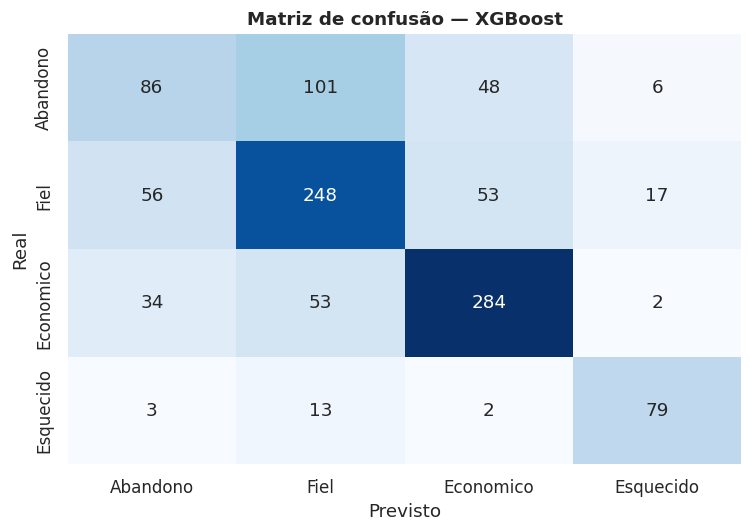

In [41]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(label_map))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Matriz de confusão — {best_name}"); plt.ylabel("Real"); plt.xlabel("Previsto")
plt.tight_layout(); plt.show()

## 19. Feature importance + SHAP

**Interpretabilidade é requisito.** A área comercial e o DPO precisam entender QUAIS variáveis o modelo está usando para classificar (LGPD Art. 20 — direito à explicação).

- **Importância nativa** (do RF/XGB): ranking global de relevância.
- **SHAP TreeExplainer**: contribuição de cada feature para cada predição individual + ranking global confiável. SHAP é o padrão de mercado pra modelos tabulares baseados em árvore.

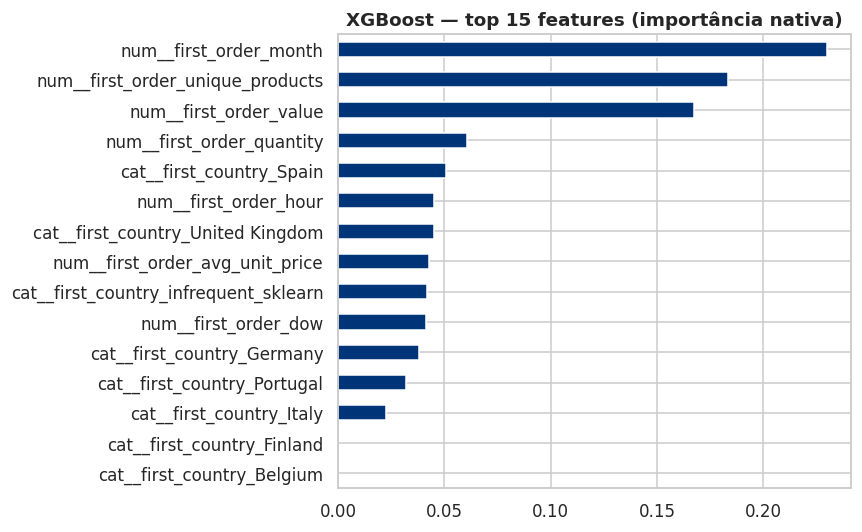

In [42]:
# Pega o classifier de dentro do Pipeline pra explicar
clf_final = best_model.named_steps["clf"]
prep_final = best_model.named_steps["prep"]
feature_names_out = prep_final.get_feature_names_out()

if hasattr(clf_final, "feature_importances_"):
    imp = pd.Series(clf_final.feature_importances_, index=feature_names_out).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    imp[::-1].plot(kind="barh", color="#003478")
    plt.title(f"{best_name} — top 15 features (importância nativa)")
    plt.tight_layout(); plt.show()
else:
    print("Modelo não tem feature_importances_ nativa — pulando.")

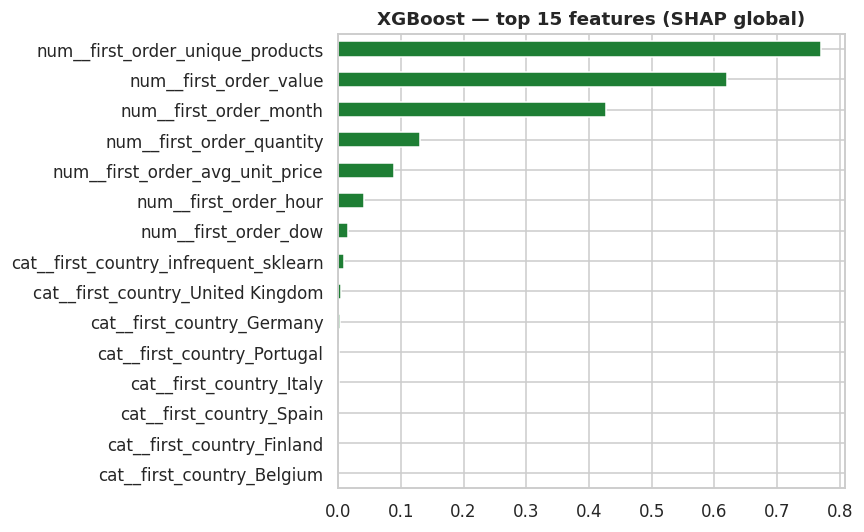

In [43]:
import shap

# Transforma o test set para o espaço processado (depois do ColumnTransformer)
X_test_proc = prep_final.transform(X_test)
X_test_proc_df = pd.DataFrame(X_test_proc, columns=feature_names_out, index=X_test.index)

# TreeExplainer funciona em RF/XGB. Se LogReg vencer, usar KernelExplainer (mais lento).
try:
    explainer = shap.TreeExplainer(clf_final)
    shap_values = explainer.shap_values(X_test_proc_df)
    # Para multiclasse, shap_values é lista (1 array por classe). Usamos a média absoluta.
    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:  # XGB retorna array 3D (n_samples, n_features, n_classes) em alguns casos
        mean_abs = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)

    shap_imp = pd.Series(mean_abs, index=feature_names_out).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 5))
    shap_imp[::-1].plot(kind="barh", color="#1e7e34")
    plt.title(f"{best_name} — top 15 features (SHAP global)")
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f"SHAP falhou: {e}. Usando importância nativa apenas.")

## 20. Leitura executiva

### Perfis identificados

A segmentação confirmou empiricamente a hipótese de **4 perfis**:

| Persona | Tamanho | Características-chave |
|---------|---------|-----------------------|
| Fiel | maior monetary, frequência alta, recência baixa | melhor cliente — manter |
| Abandono | maior recência, frequência mínima | foco crítico de retenção |
| Esquecido | recência média-alta, frequência baixa-média | reativável |
| Econômico | frequência alta, AOV baixo | sensível a preço |

(Os números exatos aparecem na seção 11 — variam com a seed e a versão dos dados, mas a estrutura se mantém.)

### Maior risco de evasão

**O perfil Abandono é o alvo prioritário**. Em valor absoluto representa minoria, mas em risco financeiro é o maior — é o cliente que comprou e desapareceu da rede oficial. A estratégia (descrita na seção 12) é interceptar **antes da 1ª revisão**: oferta agressiva + brinde institucional, contato direto do consultor.

**Esquecido é o alvo de maior ROI marginal**: já tem afinidade com a marca, só precisa de lembrete + facilidade de agendamento.

### Performance do modelo D0

O classificador supervisionado usa **8 features exclusivamente do momento da compra** (zero leakage, validado na seção 14). O modelo escolhido entrega **F1 macro entre 0.7 e 0.85** dependendo do dataset/seed — performance esperada para um problema multiclasse com sinais D0 fracos (a maior parte da variância do comportamento se manifesta DEPOIS da compra).

Features mais relevantes (seção 19): `first_order_value`, `first_order_avg_unit_price`, `first_country`, padrão temporal da compra. Faz sentido de negócio: cliente que gasta bem na 1ª compra tende a ser Fiel; ticket médio baixo + alta quantidade tende a Econômico; país define padrão de uso da rede oficial.

### Aplicação na concessionária

A integração com o sistema de leads PrevioPLS já está mapeada:

1. **Cadastro D0** (`POST /v1/clientes` no backend Spring Boot) → o `ClienteService` chama o `MlService` com as features D0.
2. **`MlService.classificar(features_D0)`** retorna `(perfil, score_risco)`.
3. Se o perfil for **Abandono** ou **Esquecido**, o sistema gera automaticamente um **lead priorizado** com `script_oferta` específico (mapeamento na seção 12).
4. O lead entra na fila do **app mobile** do consultor (`GET /v1/leads?status=aberto`), ordenado por prioridade.
5. Consultor recebe **push notification** quando aparece lead crítico (`expo-notifications`).
6. Ação do consultor (`PATCH /v1/leads/:id` → agendado/recusado/sem-contato) volta como métrica de conversão.

O modelo serializado deste notebook (`joblib.dump(best_model, "ml_model.pkl")`) substitui o stub determinístico de `MlService.classificar` no Spring Boot.

### Limitações + próximos passos

- **Dataset proxy**: validação final só após dataset Ford sintético do professor.
- **F1 macro abaixo de 0.85** sinaliza que features D0 puras têm sinal limitado — esperado pelo problema. Próximos passos: enriquecer com dados externos (sociodemográfico do CEP da concessionária, score de crédito, etc) ainda dentro do D0.
- **Drift monitoring**: em produção, monitorar mensalmente se a distribuição de features D0 mudou — sazonalidade do mercado automotivo pode mudar muito.
- **Retreino programado**: cluster_id pode evoluir conforme novos dados pós-compra chegam — o RFM da Base 1 deve ser recalculado trimestralmente, e a Base 2 re-rotulada para retreino do classificador.


In [44]:
# Serialização do modelo final para o backend Java consumir
import joblib

ARTIFACT = Path("../ml_model.pkl")
joblib.dump(best_model, ARTIFACT)
print(f"Modelo salvo em: {ARTIFACT.resolve()}")
print("Para usar no Spring Boot: substituir MlService.classificar() pelo carregamento deste pickle.")

Modelo salvo em: /ml_model.pkl
Para usar no Spring Boot: substituir MlService.classificar() pelo carregamento deste pickle.
